# IMDB Dataset Exploration

## Overview

When I first loaded this data, my immediate goal was to understand its scale and structure.
- I started by using .head() to view the first few rows and using .info to get an overview of the columns, data types, and more.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
df=pd.read_csv("imdb_top_1000.csv")
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


I then wanted to understand the data distribution for numerical columns. Therefore I used .describe() to show the following:
- count: how many values in the column
- mean: average rating
- std: how far apart the datapoints/parameters are 
- min: lowest parameter
- 25%: 25th percentile
- 50%: 50th percentile (median)
- 75% value: percentile value, 25% of rating parameters are above this value
- max: highest value

In [7]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


The mean and the 75th percentile gave me a good indicator for what a "good" movie is in this collection. However, averages don't show everything. So to explore more, I looked at the variance and standard deviation of the ratings.

## IMDB Ratings

In [8]:
variance=df['Rating'].var()
print(f'IMDB Rating Variance: {variance:.2f}')
std_dev=df['Rating'].std()
print(f'IMDB Rating Standard Deviation: {std_dev:.2f}')

IMDB Rating Variance: 0.89
IMDB Rating Standard Deviation: 0.95


- The standard deviation and variance are relatively low, which shows that the audiences generally agree on the quality of the films, and there are not many outliers.

To visualize the spread of values, I plotted a boxplot of the ratings.

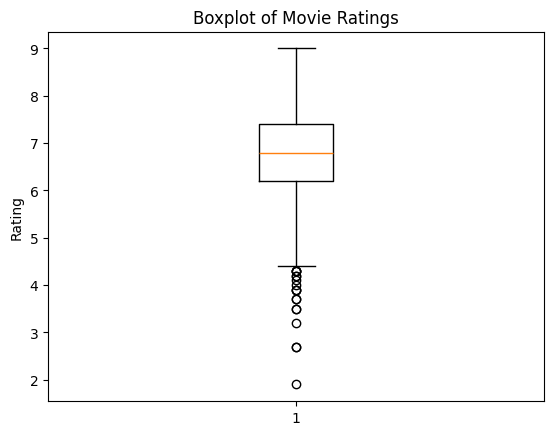

In [9]:
plt.boxplot(df["Rating"])
plt.ylabel("Rating")
plt.title("Boxplot of Movie Ratings")
plt.show()

## Runtime Distribution
Next, I investigated the actual length of these films. I plotted a histogram of the 'Runtime (Minutes)' column to find out.

<Axes: >

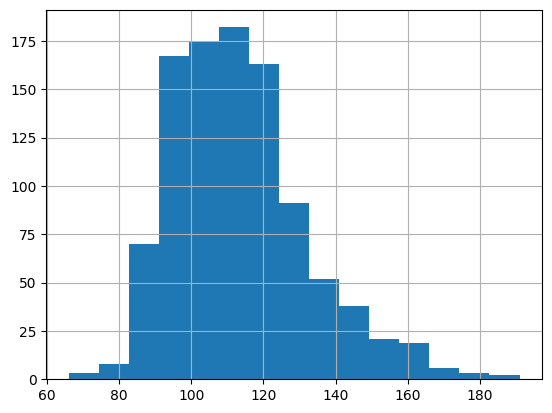

In [10]:
df['Runtime (Minutes)'].hist(bins=15) #put column name in square brackets and bins in round brackets

**Observations**
- Runtimes are not evenly distributed, instead they form a bell-shaped curve
- Most values are clustered around 90 to 120 minutes
- The distribution is also right-skwed, so there are less films stretching past 140-minute mark

Then, I looked at specific types of movies, like the best and the worst

Using, .tail() and .head() I found the Top 10 highest-rated and bottom 5 lowest-rated movies

In [11]:
newdf=df[['Title', 'Rating']] #grab two columns and create newdf 
newdf.sort_values(by='Rating').tail(10) #sort rating and print tail because sorts in ascending order

,Title,Rating
991,Taare Zameen Par,8.5
99,The Departed,8.5
124,The Dark Knight Rises,8.5
133,Whiplash,8.5
96,Kimi no na wa,8.6
36,Interstellar,8.6
249,The Intouchables,8.6
117,Dangal,8.8
80,Inception,8.8
54,The Dark Knight,9.0


In [13]:
newdf.sort_values(by='Rating').head()

,Title,Rating
829,Disaster Movie,1.9
42,Don't Fuck in the Woods,2.7
871,Dragonball Evolution,2.7
647,Tall Men,3.2
968,Wrecker,3.5


I also looked at ratings strictly above 8.5

In [14]:
high_rating=df[df['Rating']>8.5]
print(len(high_rating))

6


I also combined filters, searching for movies with a rating greater than 8.0 and a runtime of under 100 minutes

In [15]:
short_high_rated=df[(df["Rating"] > 8.0) & (df["Runtime (Minutes)"] < 100)]
print(short_high_rated)

     Rank                           Title                       Genre  \
154   155  Twin Peaks: The Missing Pieces        Drama,Horror,Mystery   
238   239        The Grand Budapest Hotel      Adventure,Comedy,Drama   
241   242                      Inside Out  Animation,Adventure,Comedy   
478   479                  Paint It Black                       Drama   
499   500                              Up  Animation,Adventure,Comedy   
634   635                          WALL·E  Animation,Adventure,Family   
695   696             Hachi: A Dog's Tale                Drama,Family   
772   773        How to Train Your Dragon  Animation,Action,Adventure   

                                           Description         Director  \
154  Twin Peaks before Twin Peaks (1990) and at the...      David Lynch   
238  The adventures of Gustave H, a legendary conci...     Wes Anderson   
241  After young Riley is uprooted from her Midwest...      Pete Docter   
478  A young woman attempts to deal with t

## Correlations

To see if there was a mathematical relationship between different variables, I generated a correlation matrix using .corr().

In [19]:
dfnumeric=df[['Votes','Runtime (Minutes)','Rating']]
corr_matrix=dfnumeric.corr()
print(corr_matrix)

                      Votes  Runtime (Minutes)    Rating
Votes              1.000000           0.407062  0.511537
Runtime (Minutes)  0.407062           1.000000  0.392214
Rating             0.511537           0.392214  1.000000


- .corr() only works on numeric columns
- 1.0 -> strong positive correlation
- -1 -> strong negative correlation
- 0 -> weak or no correlation
- these all have a positive correlaton to each other

In [18]:
print(corr_matrix["Rating"].sort_values(ascending=False))

Rating               1.000000
Votes                0.511537
Runtime (Minutes)    0.392214
Name: Rating, dtype: float64


## Groupings

By grouping the dataset by Genre, I could calculate the average rating for each category and see which genre consistently delivers the highest quality.

In [20]:
genre_ratings=df.groupby("Genre")["Rating"].mean().sort_values()
print(genre_ratings)

Genre
Fantasy,Horror,Thriller    3.20
Comedy,Western             4.80
Sci-Fi                     4.95
Sci-Fi,Thriller            5.00
Action,Fantasy,Thriller    5.20
                           ... 
Adventure,Drama,Sci-Fi     8.30
Animation,Drama,Romance    8.40
Drama,Western              8.40
Drama,Family,Music         8.50
Animation,Drama,Fantasy    8.60
Name: Rating, Length: 207, dtype: float64


In [21]:
print(f'Highest average rating genre: {genre_ratings.idxmax()}')
print(f'Average rating: {genre_ratings.max()}')

Highest average rating genre: Animation,Drama,Fantasy
Average rating: 8.6


In [22]:
avg_rating_by_year=df.groupby("Year")["Rating"].mean()
print(avg_rating_by_year)

Year
2006    7.125000
2007    7.133962
2008    6.784615
2009    6.960784
2010    6.826667
2011    6.838095
2012    6.925000
2013    6.812088
2014    6.837755
2015    6.602362
2016    6.436700
Name: Rating, dtype: float64


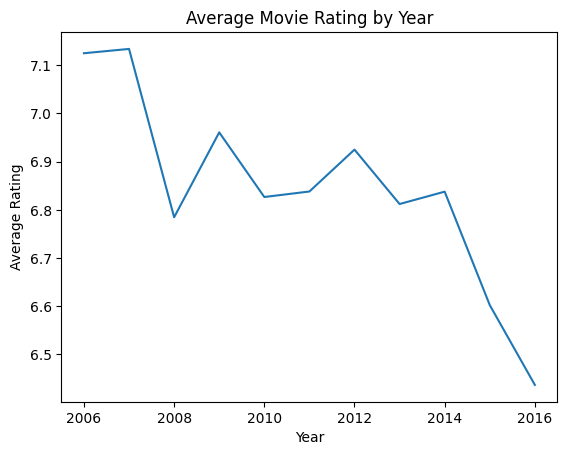

In [35]:
avg_rating_by_year.plot(kind="line")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Year")
plt.show()

Finally, I used .value_counts() to the Director column and with .head(3) to identify the top three most frequently occurring directors in this collection

In [45]:
df.value_counts('Director').head(3)

Director
Ridley Scott          8
M. Night Shyamalan    6
David Yates           6
Name: count, dtype: int64

## Cleaning Data

In [17]:
print(df.isnull().sum())

Rank                    0
Title                   0
Genre                   0
Description             0
Director                0
Actors                  0
Year                    0
Runtime (Minutes)       0
Rating                  0
Votes                   0
Revenue (Millions)    128
Metascore              64
dtype: int64


In [32]:
df_clean = df.dropna()
print(len(df_clean))

838


## Detecting Outliers

To find these extremely long films, I first calculated the exact mean and standard deviation of the Runtime column. Then, I filtered the dataset to isolate any movie whose runtime exceeded the mean plus two stddev threshold.

In [23]:
runtime_mean=df['Runtime (Minutes)'].mean()
runtime_std=df['Runtime (Minutes)'].std()
outliers=df[df['Runtime (Minutes)'] > (runtime_mean + (2 * runtime_std))]
print(outliers[['Title', 'Runtime (Minutes)']])

                                                 Title  Runtime (Minutes)
26                             Bahubali: The Beginning                159
36                                        Interstellar                169
54                                     The Dark Knight                152
55                                             Silence                161
60                  Batman v Superman: Dawn of Justice                151
75            Pirates of the Caribbean: At World's End                169
77                                Inglourious Basterds                153
78          Pirates of the Caribbean: Dead Man's Chest                151
82                             The Wolf of Wall Street                180
87                                              Avatar                162
88                                   The Hateful Eight                187
90                                           Prisoners                153
99                                    

- all of these movies above were very long compared to the average movie length

In [24]:
df.groupby('Genre')['Votes'].max()

Genre
Action                         10428
Action,Adventure              474320
Action,Adventure,Biography     90372
Action,Adventure,Comedy       627797
Action,Adventure,Crime        501769
                               ...  
Romance,Sci-Fi,Thriller       208632
Sci-Fi                          1176
Sci-Fi,Thriller               170897
Thriller                      220236
Thriller,War                    5926
Name: Votes, Length: 207, dtype: int64

## More Explorations

### Data Cleaning

The data has already been cleaned, but if the data in the cells had been a string (e.g.,"142 min"). Then the code below would be to change that into an integer

In [ ]:
df['Runtime (Minutes)']=df['Runtime (Minutes)'].str.replace(r'\D', '', regex=True).astype(int)

Same as above, but changing the revenue into integers, and filling the empty values with median

In [ ]:
#4 exploration
df['Revenue (Millions)']=df['Revenue (Millions)'].str.replace(r'[$,]', '', regex=True).astype(float)
df['Revenue (Millions)']=df['Revenue (Millions)'].fillna(df['Revenue (Millions)'].median())

### Grouping and Aggregtion

Instead of running separate commands, I used the .agg() method to simultaneously calculate the mean, median, and standard deviation of their IMDB ratings, group by directors

In [27]:
#2 .agg() accepts a list of statistical functions to apply to the rating column
cert_stats=df.groupby("Director")["Rating"].agg(['mean', 'median', 'std'])
print(cert_stats)

                     mean  median       std
Director                                   
Aamir Khan           8.50    8.50       NaN
Abdellatif Kechiche  7.80    7.80       NaN
Adam Leon            6.50    6.50       NaN
Adam McKay           7.00    6.80  0.547723
Adam Shankman        6.30    6.30  0.565685
...                   ...     ...       ...
Xavier Dolan         7.55    7.55  0.777817
Yimou Zhang          6.10    6.10       NaN
Yorgos Lanthimos     7.20    7.20  0.141421
Zack Snyder          7.04    7.10  0.661816
Zackary Adler        5.10    5.10       NaN

[644 rows x 3 columns]


By using groupby() on the release year with .idxmax() on the rating, I was able to fine exact index of the highest-rated film annually and extract those specific rows.

In [38]:
#7. idxmax() finds the row index of the max value and .loc[] retrieves those specific rows
idx_best_per_year = df.groupby("Year")["Rating"].idxmax()
best_movies_per_year = df.loc[idx_best_per_year]
print(idx_best_per_year)
print(best_movies_per_year)

Year
2006     64
2007    991
2008     54
2009    430
2010     80
2011    249
2012    124
2013     82
2014     36
2015     26
2016    117
Name: Rating, dtype: int64
     Rank                    Title                    Genre  \
64     65             The Prestige     Drama,Mystery,Sci-Fi   
991   992         Taare Zameen Par       Drama,Family,Music   
54     55          The Dark Knight       Action,Crime,Drama   
430   431                 3 Idiots             Comedy,Drama   
80     81                Inception  Action,Adventure,Sci-Fi   
249   250         The Intouchables   Biography,Comedy,Drama   
124   125    The Dark Knight Rises          Action,Thriller   
82     83  The Wolf of Wall Street   Biography,Comedy,Crime   
36     37             Interstellar   Adventure,Drama,Sci-Fi   
26     27  Bahubali: The Beginning   Action,Adventure,Drama   
117   118                   Dangal   Action,Biography,Drama   

                                           Description           Director  \
64

### Sorting and Filtering

To find the best movies, I sorted the dataset by Rating and Votes simultaneously—both in descending order

In [41]:
#3. the ascending list [False, False] makes both columns sort in descending order
df_sorted=df.sort_values(by=["Rating", "Votes"], ascending=[False, False])
print(df_sorted)

     Rank                    Title                     Genre  \
54     55          The Dark Knight        Action,Crime,Drama   
80     81                Inception   Action,Adventure,Sci-Fi   
117   118                   Dangal    Action,Biography,Drama   
36     37             Interstellar    Adventure,Drama,Sci-Fi   
249   250         The Intouchables    Biography,Comedy,Drama   
..    ...                      ...                       ...   
890   891               The Intent               Crime,Drama   
647   648                 Tall Men   Fantasy,Horror,Thriller   
871   872     Dragonball Evolution  Action,Adventure,Fantasy   
42     43  Don't Fuck in the Woods                    Horror   
829   830           Disaster Movie                    Comedy   

                                           Description           Director  \
54   When the menace known as the Joker wreaks havo...  Christopher Nolan   
80   A thief, who steals corporate secrets through ...  Christopher Nolan   


I used the .isin() method to filter the massive dataset down to only the movies that match those exact categories.

In [28]:
#6 -> using .isin() for specific genres
genres=['Action', 'Sci-Fi', 'Drama']
filtered_genres=df[df['Genre'].isin(genres)]
print(filtered_genres)

     Rank                           Title   Genre  \
21     22           Manchester by the Sea   Drama   
41     42                       Moonlight   Drama   
44     45                       Lowriders   Drama   
49     50                   The Last Face   Drama   
68     69                       Wakefield   Drama   
92     93                        The Help   Drama   
108   109                      All We Had   Drama   
123   124            Boyka: Undisputed IV  Action   
130   131                          Fences   Drama   
143   144                            Room   Drama   
152   153                      White Girl   Drama   
183   184                         Realive  Sci-Fi   
191   192                 Below Her Mouth   Drama   
211   212                 Spring Breakers   Drama   
225   226                  American Honey   Drama   
263   264            Nymphomaniac: Vol. I   Drama   
293   294                   The Exception   Drama   
321   322                        Lovesong   Dr

In [29]:
#9
high_rated=df.query('Rating > 8.0 and Votes > 100000')
print(high_rated)

     Rank                                         Title  \
0       1                       Guardians of the Galaxy   
6       7                                    La La Land   
16     17                                 Hacksaw Ridge   
18     19                                          Lion   
36     37                                  Interstellar   
50     51    Star Wars: Episode VII - The Force Awakens   
54     55                               The Dark Knight   
64     65                                  The Prestige   
67     68                            Mad Max: Fury Road   
74     75                                      Zootopia   
76     77                                  The Avengers   
77     78                          Inglourious Basterds   
80     81                                     Inception   
82     83                       The Wolf of Wall Street   
83     84                                     Gone Girl   
90     91                                     Prisoners 

### Restructuring

Using the pd.cut() function, I binned the continuous runtime data into three distinct new categories: "Short" (0–90 mins), "Standard" (90–150 mins), and "Epic" (150+ mins).

In [30]:
#5 
df['Movie_Length']=pd.cut(df['Runtime (Minutes)'], bins=[0, 90, 150, 500], labels=["Short", "Standard", "Epic"])
print(df['Movie_Length'])

0      Standard
1      Standard
2      Standard
3      Standard
4      Standard
         ...   
995    Standard
996    Standard
997    Standard
998    Standard
999       Short
Name: Movie_Length, Length: 1000, dtype: category
Categories (3, object): ['Short' < 'Standard' < 'Epic']


The Genre column contained multiple tags separated by commas. I split these strings into lists and used the .explode() method to give every individual genre tag its own dedicated row.

In [31]:
#8
df['Genre']=df['Genre'].str.split(',')#split the string into a python list of strings
df_exploded=df.explode('Genre')#explode stretches those lists out so every genre gets its own row
print(df_exploded[['Title', 'Genre']].head(10))

                     Title      Genre
0  Guardians of the Galaxy     Action
0  Guardians of the Galaxy  Adventure
0  Guardians of the Galaxy     Sci-Fi
1               Prometheus  Adventure
1               Prometheus    Mystery
1               Prometheus     Sci-Fi
2                    Split     Horror
2                    Split   Thriller
3                     Sing  Animation
3                     Sing     Comedy
